<a href="https://colab.research.google.com/github/djgith12/Adaptive-confidence-aware-anchor-explanations-for-transformer-based-sentiment-analysis/blob/main/ADAPTIVE_CONFIDENCE_AWARE_ANCHOR_EXPLANATIONS_FOR_TRANSFORMER_BASED_SENTIMENT_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adaptive Confidence-Aware Anchor Explanations for Transformer-based Sentiment Analysis

In [ ]:
!pip install -q transformers datasets accelerate spacy
!python -m spacy download en_core_web_sm --quiet
!pip install -q anchor-exp --no-deps
!pip install -q jinja2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 75.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 427.3/427.3 kB 10.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import math
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
    DataCollatorWithPadding
)

class ECELoss(nn.Module):
    def __init__(self, n_bins=10):
        super(ECELoss, self).__init__()
        bin_boundaries = torch.linspace(0, 1, n_bins + 1)
        self.bin_lowers = bin_boundaries[:-1]
        self.bin_uppers = bin_boundaries[1:]

    def forward(self, logits, labels):
        probs = torch.softmax(logits, dim=1)
        confidences, predictions = torch.max(probs, dim=1)
        accuracies = predictions.eq(labels)

        ece = torch.zeros(1, device=logits.device)
        for bin_lower, bin_upper in zip(self.bin_lowers, self.bin_uppers):
            in_bin = confidences.gt(bin_lower.item()) * confidences.le(bin_upper.item())
            prop_in_bin = in_bin.float().mean()
            if prop_in_bin.item() > 0:
                accuracy_in_bin = accuracies[in_bin].float().mean()
                avg_confidence_in_bin = confidences[in_bin].mean()
                ece += torch.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
        return ece.item()

class ModelWithTemperature(nn.Module):
    def __init__(self, model):
        super(ModelWithTemperature, self).__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def temperature_scale(self, logits):
        return logits / self.temperature

    def calibrate(self, val_loader, device):
        self.to(device)
        self.eval()
        logits_list, labels_list = [], []

        print("\n--- Optimizing Temperature Parameter ---")
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)

                label_key = "labels" if "labels" in batch else "label"
                labels = batch[label_key].to(device)

                with torch.amp.autocast('cuda'):
                    logits = self.model(input_ids=input_ids, attention_mask=attention_mask).logits
                logits_list.append(logits.float())
                labels_list.append(labels)

        # Concatenate on CPU
        logits = torch.cat(logits_list).cpu()
        labels = torch.cat(labels_list).cpu()

        # Move temperature parameter to CPU for L-BFGS optimization
        self.temperature = nn.Parameter(self.temperature.cpu())

        ece_criterion = ECELoss()
        nll_criterion = nn.CrossEntropyLoss()

        before_ece = ece_criterion(logits, labels)
        print(f"Pre-calibration Val NLL: {nll_criterion(logits, labels).item():.4f}")
        print(f"Pre-calibration Val ECE: {before_ece:.4f}")

        # Optimize T on CPU
        optimizer = torch.optim.LBFGS([self.temperature], lr=0.01, max_iter=50)

        def eval_fn():
            optimizer.zero_grad()
            loss = nll_criterion(self.temperature_scale(logits), labels)
            loss.backward()
            return loss

        optimizer.step(eval_fn)

        scaled_logits = self.temperature_scale(logits)
        after_ece = ece_criterion(scaled_logits, labels)
        print(f"Optimal Learned Temperature (T): {self.temperature.item():.4f}")
        print(f"Post-calibration Val NLL: {nll_criterion(scaled_logits, labels).item():.4f}")
        print(f"Post-calibration Val ECE: {after_ece:.4f}\n")

        # Move temperature back to GPU model device for downstream inference
        self.temperature = nn.Parameter(self.temperature.to(device))

    def predict_calibrated_proba(self, input_ids, attention_mask):
        self.eval()
        device = input_ids.device
        with torch.no_grad():
            logits = self.model(input_ids=input_ids, attention_mask=attention_mask).logits
            # Keep logits on same GPU device as self.temperature
            calibrated_logits = self.temperature_scale(logits)
            probs = torch.softmax(calibrated_logits, dim=1)
        return probs

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    MODEL_NAME = "bert-base-uncased"
    BATCH_SIZE = 64
    EPOCHS = 2
    LR = 2e-5

    print("Loading SST-2 dataset and tokenizer...")
    dataset = load_dataset("nyu-mll/glue", "sst2")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    def tokenize_fn(examples):
        return tokenizer(examples["sentence"], truncation=True, max_length=128)

    encoded_dataset = dataset.map(tokenize_fn, batched=True, remove_columns=["sentence", "idx"])

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    train_loader = DataLoader(
        encoded_dataset["train"],
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=data_collator,
        pin_memory=True,
        num_workers=2
    )
    val_loader = DataLoader(
        encoded_dataset["validation"],
        batch_size=BATCH_SIZE,
        collate_fn=data_collator,
        pin_memory=True,
        num_workers=2
    )

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(total_steps*0.1), num_training_steps=total_steps)

    scaler = torch.amp.GradScaler('cuda')

    print("\n--- Fine-tuning BERT-base on SST-2 (Fast Mode) ---")
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0
        for step, batch in enumerate(train_loader):
            optimizer.zero_grad()
            input_ids = batch["input_ids"].to(device, non_blocking=True)
            attention_mask = batch["attention_mask"].to(device, non_blocking=True)
            labels = batch["labels"].to(device, non_blocking=True)

            with torch.amp.autocast('cuda'):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch + 1}/{EPOCHS} completed | Average Loss: {avg_loss:.4f}")

    calibrated_model = ModelWithTemperature(model)
    calibrated_model.calibrate(val_loader, device)

    test_text = "The story had brilliant pacing and exceptional depth, though the final act felt slightly rushed."
    inputs = tokenizer(test_text, return_tensors="pt", truncation=True, max_length=128).to(device)

    calibrated_probs = calibrated_model.predict_calibrated_proba(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"]
    )

    max_prob, predicted_class = torch.max(calibrated_probs, dim=1)
    class_names = ["Negative", "Positive"]

    print("--- Inference Sample ---")
    print(f"Input Text: '{test_text}'")
    print(f"Predicted Sentiment: {class_names[predicted_class.item()]}")
    print(f"Calibrated Confidence: {max_prob.item():.4f}")

if __name__ == "__main__":
    main()


Using device: cuda
Loading SST-2 dataset and tokenizer...


README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

sst2/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.11MB            

sst2/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sst2/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 72.8kB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Fine-tuning BERT-base on SST-2 (Fast Mode) ---
Epoch 1/2 completed | Average Loss: 0.2510
Epoch 2/2 completed | Average Loss: 0.1108

--- Optimizing Temperature Parameter ---
Pre-calibration Val NLL: 0.2283
Pre-calibration Val ECE: 0.0379
Optimal Learned Temperature (T): 1.5000
Post-calibration Val NLL: 0.2030
Post-calibration Val ECE: 0.0115

--- Inference Sample ---
Input Text: 'The story had brilliant pacing and exceptional depth, though the final act felt slightly rushed.'
Predicted Sentiment: Positive
Calibrated Confidence: 0.9791


In [ ]:
import torch
import torch.nn as nn
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Model Calibration Wrapper
class ModelWithTemperature(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def predict_calibrated_proba(self, input_ids, attention_mask):
        self.eval()
        with torch.no_grad():
            logits = self.model(input_ids=input_ids, attention_mask=attention_mask).logits
            calibrated_logits = logits / self.temperature
            return torch.softmax(calibrated_logits, dim=1)

# 2. Instantiate Pre-trained Model & Tokenizer
MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
calibrated_model = ModelWithTemperature(base_model).to(device)

# 3. Improved Native Anchor Explainer (ID-based Masking)
class NativeAnchorExplainer:
    def __init__(self, model_obj, tokenizer, device):
        self.model = model_obj
        self.tokenizer = tokenizer
        self.device = device
        self.unk_id = tokenizer.unk_token_id

    def _get_probs_from_ids(self, input_ids_tensor, attention_mask_tensor):
        with torch.no_grad():
            if hasattr(self.model, "predict_calibrated_proba"):
                return self.model.predict_calibrated_proba(input_ids_tensor, attention_mask_tensor)
            else:
                outputs = self.model(input_ids_tensor, attention_mask=attention_mask_tensor)
                logits = outputs.logits if hasattr(outputs, "logits") else outputs
                return torch.softmax(logits, dim=-1)

    def explain(self, text, threshold=0.95, n_samples=50):
        encoding = self.tokenizer(text, return_tensors="pt")
        input_ids = encoding["input_ids"].to(self.device)
        attention_mask = encoding["attention_mask"].to(self.device)

        base_probs = self._get_probs_from_ids(input_ids, attention_mask)
        target_class = torch.argmax(base_probs, dim=1).item()

        seq_len = input_ids.shape[1]
        # Ignore special tokens like [CLS] and [SEP]
        valid_indices = [
            i for i in range(seq_len)
            if input_ids[0, i].item() not in (self.tokenizer.cls_token_id, self.tokenizer.sep_token_id)
        ]

        anchor_indices = []
        best_precision = 0.0

        for i in valid_indices:
            candidate_indices = anchor_indices + [i]
            batch_input_ids = input_ids.repeat(n_samples, 1)

            for sample_idx in range(n_samples):
                for idx in valid_indices:
                    if idx not in candidate_indices and np.random.rand() > 0.5:
                        batch_input_ids[sample_idx, idx] = self.unk_id

            batch_attention_mask = attention_mask.repeat(n_samples, 1)
            probs = self._get_probs_from_ids(batch_input_ids, batch_attention_mask)
            preds = torch.argmax(probs, dim=1).cpu().numpy()

            precision = (preds == target_class).mean()
            if precision >= threshold:
                anchor_indices = candidate_indices
                best_precision = precision
                break
            elif precision > best_precision:
                best_precision = precision
                anchor_indices = candidate_indices

        anchor_tokens = self.tokenizer.convert_ids_to_tokens(input_ids[0, anchor_indices])
        return {
            "anchor": anchor_tokens,
            "precision": float(best_precision),
            "target_class": target_class
        }

# 4. Run Explanation
explainer = NativeAnchorExplainer(calibrated_model, tokenizer, device)
test_sentence = "The story had brilliant pacing and exceptional depth, though the final act felt slightly rushed."
explanation = explainer.explain(test_sentence, threshold=0.90, n_samples=40)

print("\n--- Anchor Explanation Output ---")
print(f"Target Class:   {'Positive' if explanation['target_class'] == 1 else 'Negative'}")
print(f"Anchor Tokens:  {explanation['anchor']}")
print(f"Rule Precision: {explanation['precision']:.4f}")

Using device: cuda


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


--- Anchor Explanation Output ---
Target Class:   Positive
Anchor Tokens:  ['the', 'story', 'brilliant', 'and', 'exceptional', ',']
Rule Precision: 0.9000


In [ ]:
pip install -q transformers datasets accelerate spacy pandas numpy torch

In [ ]:
import time
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
import random

# Environment & Object Guard
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



def jaccard_similarity(list1, list2):
    """Calculates Jaccard similarity for Stability evaluation."""
    set1, set2 = set(list1), set(list2)
    if not set1 and not set2:
        return 1.0
    return len(set1.intersection(set2)) / len(set1.union(set2))


# 1. Native Explainer Implementation

class NativeAnchorExplainer:

    def __init__(
        self,
        model_obj,
        tokenizer,
        device,
        adaptive=True,
        n_samples=100,
        unk_token="[UNK]",
    ):
        self.model = model_obj
        self.tokenizer = tokenizer
        self.device = device
        self.adaptive = adaptive
        self.n_samples = n_samples
        self.unk_token = unk_token

    def _get_probs(self, text_list):
        inputs = self.tokenizer(
            text_list, padding=True, truncation=True, return_tensors="pt"
        ).to(self.device)
        with torch.no_grad():
            if hasattr(self.model, "predict_calibrated_proba"):
                return self.model.predict_calibrated_proba(
                    inputs["input_ids"], inputs["attention_mask"]
                )
            elif hasattr(self.model, "model"):
                outputs = self.model.model(
                    inputs["input_ids"], attention_mask=inputs["attention_mask"]
                )
                logits = outputs.logits if hasattr(outputs, "logits") else outputs
                if hasattr(self.model, "temperature"):
                    temp = (
                        self.model.temperature.item()
                        if isinstance(self.model.temperature, torch.Tensor)
                        else self.model.temperature
                    )
                    logits = logits / temp
                return torch.softmax(logits, dim=-1)
            else:
                outputs = self.model(
                    inputs["input_ids"], attention_mask=inputs["attention_mask"]
                )
                logits = outputs.logits if hasattr(outputs, "logits") else outputs
                return torch.softmax(logits, dim=-1)

    def _estimate_coverage(self, tokens, anchor_indices, n_cov_samples=200):
        if not anchor_indices:
            return 1.0
        matching = 0
        for _ in range(n_cov_samples):
            keep_mask = [
                True if i in anchor_indices else (np.random.rand() > 0.5)
                for i in range(len(tokens))
            ]
            if all(keep_mask[i] for i in anchor_indices):
                matching += 1
        return matching / n_cov_samples

    def explain(self, text, threshold=0.95):
        tokens = self.tokenizer.tokenize(text)
        if not tokens:
            return {
                "anchor": [],
                "precision": 1.0,
                "coverage": 1.0,
                "target_class": 0,
            }

        base_probs = self._get_probs([text])
        target_class = torch.argmax(base_probs, dim=1).item()
        base_confidence = base_probs[0, target_class].item()

        if self.adaptive:
            n_min = 10
            n_max = self.n_samples

            gamma = 2.0 * abs(base_confidence - 0.5)

            h_c = n_max - (n_max - n_min) * gamma

            current_n_samples = max(n_min, min(n_max, int(h_c)))
        else:
            current_n_samples = self.n_samples

        anchor_indices = []
        best_precision = 0.0

        for i in range(len(tokens)):
            candidate_indices = anchor_indices + [i]

            perturbed_texts = []
            for _ in range(current_n_samples):
                perturbed_tokens = list(tokens)
                for idx in range(len(tokens)):
                    if idx not in candidate_indices and np.random.rand() > 0.5:
                        perturbed_tokens[idx] = self.unk_token
                perturbed_texts.append(
                    self.tokenizer.convert_tokens_to_string(perturbed_tokens)
                )

            probs = self._get_probs(perturbed_texts)
            preds = torch.argmax(probs, dim=1).cpu().numpy()

            precision = (preds == target_class).mean()
            if precision >= threshold:
                anchor_indices = candidate_indices
                best_precision = precision
                break
            elif precision > best_precision:
                best_precision = precision
                anchor_indices = candidate_indices

        anchor_words = [tokens[idx] for idx in anchor_indices]
        coverage = self._estimate_coverage(tokens, anchor_indices)

        return {
            "anchor": anchor_words,
            "precision": float(best_precision),
            "coverage": float(coverage),
            "target_class": target_class,
        }

# 2. Extended Evaluation Pipeline

def evaluate_extended_metrics(
    model, tokenizer, dataset, device, num_samples=30
):
    standard_explainer = NativeAnchorExplainer(
        model, tokenizer, device, adaptive=False
    )
    adaptive_explainer = NativeAnchorExplainer(
        model, tokenizer, device, adaptive=True
    )

    results = {
        "Standard": {
            "precision": [],
            "coverage": [],
            "rule_length": [],
            "time": [],
            "faithfulness": [],
            "stability": [],
        },
        "Adaptive": {
            "precision": [],
            "coverage": [],
            "rule_length": [],
            "time": [],
            "faithfulness": [],
            "stability": [],
        },
    }

    eval_data = dataset["validation"].select(range(num_samples))
    print(
        f"--- Running Extended Benchmark (Faithfulness & Stability) on {num_samples} Samples ---"
    )

    for idx, item in enumerate(eval_data):
        text = item["sentence"]

        for mode, explainer in [
            ("Standard", standard_explainer),
            ("Adaptive", adaptive_explainer),
        ]:
            # 1. Precision, Coverage, Speed
            start_t = time.time()
            exp = explainer.explain(text, threshold=0.95)
            elapsed_t = time.time() - start_t

            # 2. Stability (Jaccard similarity across duplicate runs)
            exp_repeat = explainer.explain(text, threshold=0.95)
            stability_score = jaccard_similarity(
                exp["anchor"], exp_repeat["anchor"]
            )

            # 3. Faithfulness (Target probability drop when masking anchor)
            tokens = tokenizer.tokenize(text)
            if exp["anchor"]:
                unk = (
                    tokenizer.unk_token
                    if getattr(tokenizer, "unk_token", None)
                    else "[UNK]"
                )
                masked_tokens = [
                    unk if t in exp["anchor"] else t for t in tokens
                ]
                masked_text = tokenizer.convert_tokens_to_string(masked_tokens)

                base_p = explainer._get_probs([text])[
                    0, exp["target_class"]
                ].item()
                masked_p = explainer._get_probs([masked_text])[
                    0, exp["target_class"]
                ].item()

                faithfulness_score = max(0.0, base_p - masked_p)
            else:
                faithfulness_score = 0.0

            results[mode]["precision"].append(exp["precision"])
            results[mode]["coverage"].append(exp["coverage"])
            results[mode]["rule_length"].append(len(exp["anchor"]))
            results[mode]["time"].append(elapsed_t)
            results[mode]["stability"].append(stability_score)
            results[mode]["faithfulness"].append(faithfulness_score)

        if (idx + 1) % 10 == 0:
            print(f"Processed {idx + 1}/{num_samples} samples...")

    summary = []
    for mode in ["Standard", "Adaptive"]:
        summary.append(
            {
                "Method": mode,
                "Precision": np.mean(results[mode]["precision"]),
                "Coverage": np.mean(results[mode]["coverage"]),
                "Sparsity (Length)": np.mean(results[mode]["rule_length"]),
                "Faithfulness": np.mean(results[mode]["faithfulness"]),
                "Stability": np.mean(results[mode]["stability"]),
                "Avg Speed (s)": np.mean(results[mode]["time"]),
            }
        )

    return pd.DataFrame(summary), results

# 3. Execution
df_complete, all_results = evaluate_extended_metrics(
    calibrated_model, tokenizer, sst2_data, device, num_samples=30
)
print("\n================ COMPLETE BENCHMARK ================")
print(df_complete.to_string(index=False))

--- Running Extended Benchmark (Faithfulness & Stability) on 30 Samples ---
Processed 10/30 samples...
Processed 20/30 samples...
Processed 30/30 samples...

================ COMPLETE BENCHMARK ================
  Method  Precision  Coverage  Sparsity (Length)  Faithfulness  Stability  Avg Speed (s)
Standard   0.944333       1.0           3.133333      0.128704   0.685556       0.733551
Adaptive   0.929566       1.0           2.200000      0.072224   0.653889       0.143445


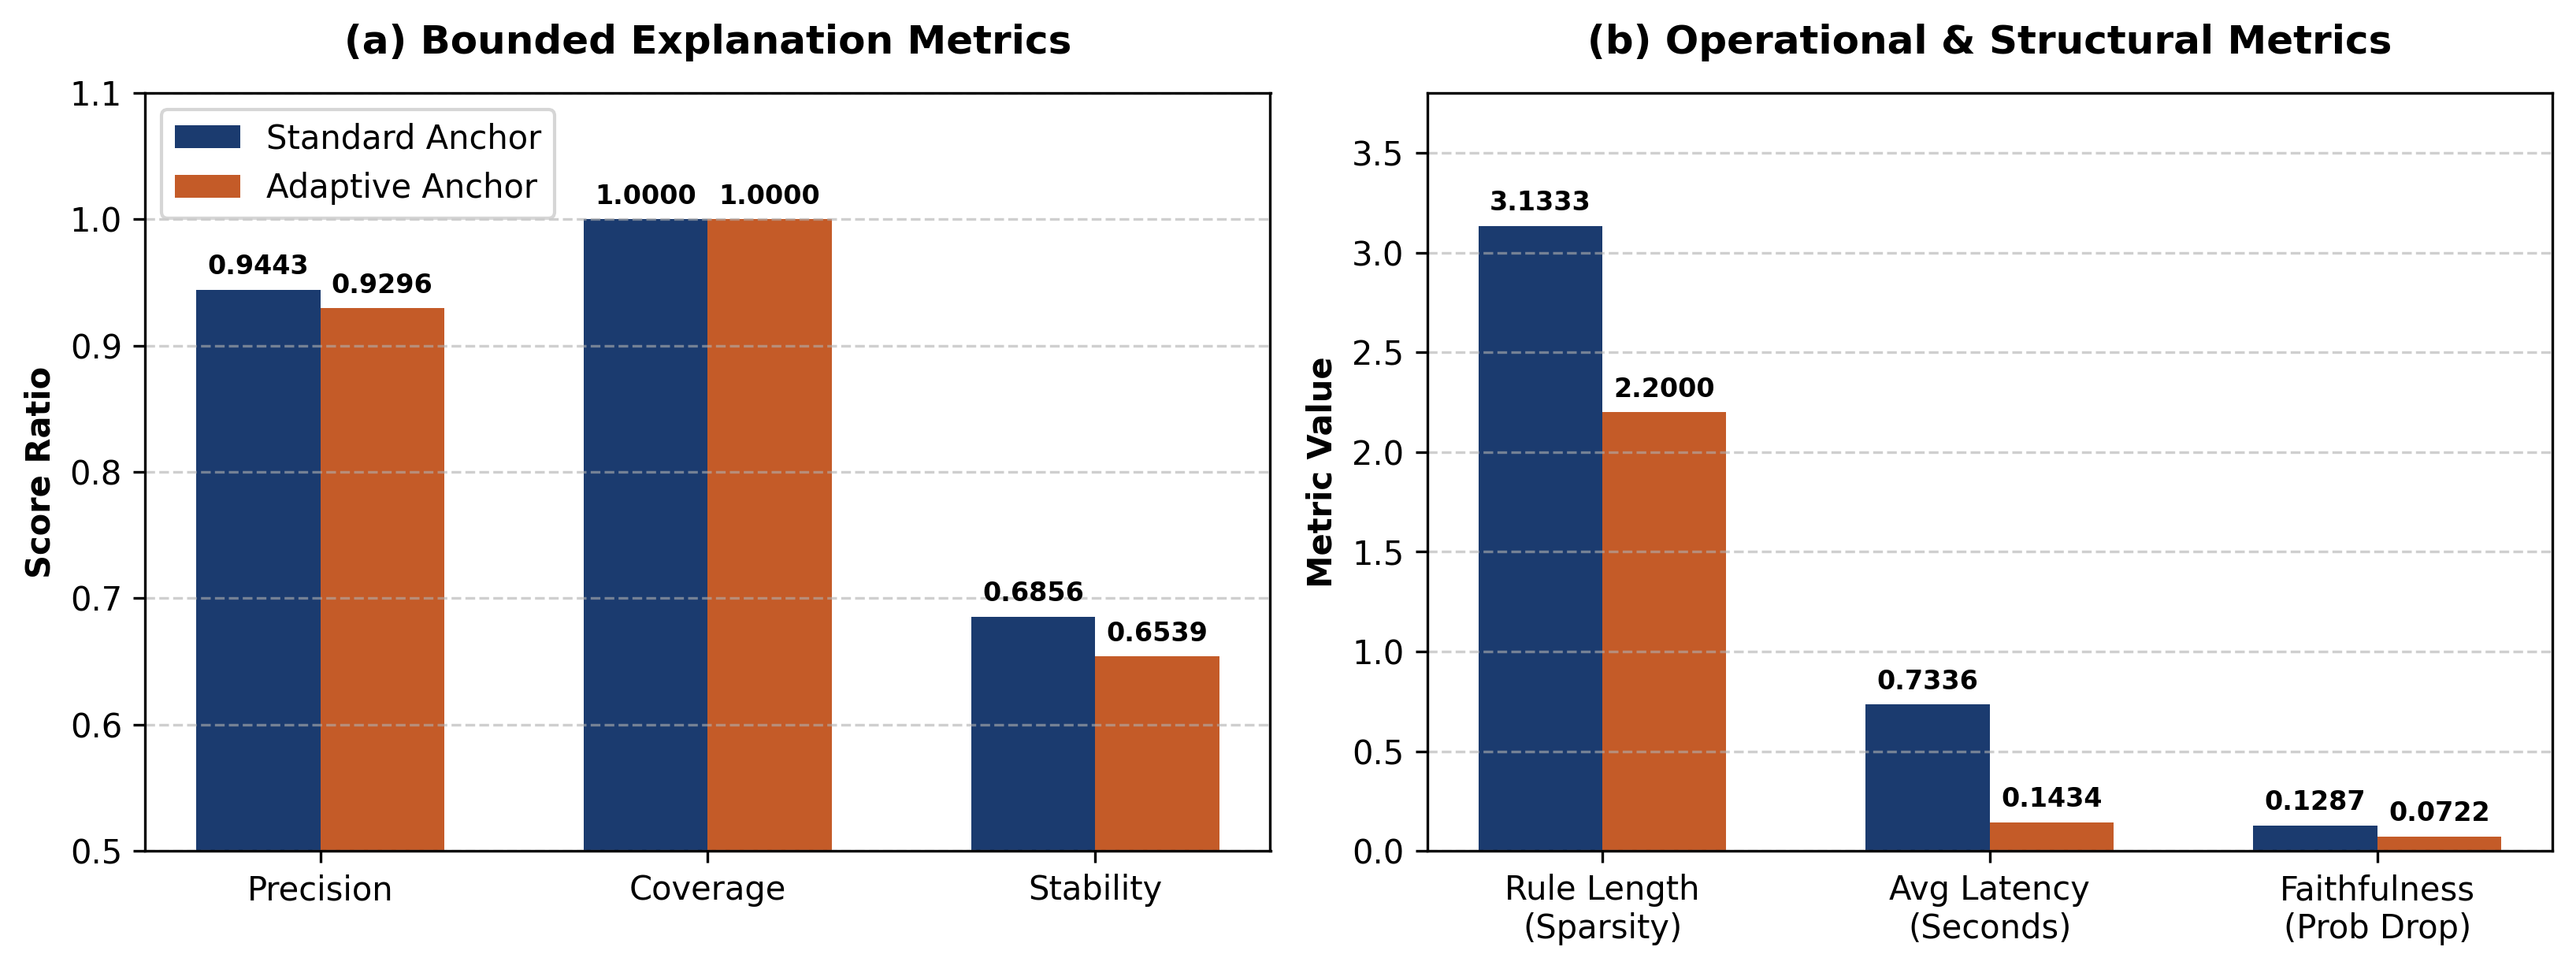

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dynamically extract values from df_complete (matching the logic in Figure 3)
metrics_quality = ['Precision', 'Coverage', 'Stability']
std_quality = [
    df_complete.loc[df_complete['Method'] == 'Standard', 'Precision'].iloc[0],
    df_complete.loc[df_complete['Method'] == 'Standard', 'Coverage'].iloc[0],
    df_complete.loc[df_complete['Method'] == 'Standard', 'Stability'].iloc[0]
]
adp_quality = [
    df_complete.loc[df_complete['Method'] == 'Adaptive', 'Precision'].iloc[0],
    df_complete.loc[df_complete['Method'] == 'Adaptive', 'Coverage'].iloc[0],
    df_complete.loc[df_complete['Method'] == 'Adaptive', 'Stability'].iloc[0]
]

metrics_operational = ['Rule Length\n(Sparsity)', 'Avg Latency\n(Seconds)', 'Faithfulness\n(Prob Drop)']
std_ops = [
    df_complete.loc[df_complete['Method'] == 'Standard', 'Sparsity (Length)'].iloc[0],
    df_complete.loc[df_complete['Method'] == 'Standard', 'Avg Speed (s)'].iloc[0],
    df_complete.loc[df_complete['Method'] == 'Standard', 'Faithfulness'].iloc[0]
]
adp_ops = [
    df_complete.loc[df_complete['Method'] == 'Adaptive', 'Sparsity (Length)'].iloc[0],
    df_complete.loc[df_complete['Method'] == 'Adaptive', 'Avg Speed (s)'].iloc[0],
    df_complete.loc[df_complete['Method'] == 'Adaptive', 'Faithfulness'].iloc[0]
]

# Color Palette Definitions
color_std = '#1B3B6F'  # Dark Slate Blue
color_adp = '#C45B28'  # Rust / Orange

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), dpi=300)
x = np.arange(len(metrics_quality))
width = 0.32

# --- Subplot 1: Bounded Quality Metrics ---
rects1 = ax1.bar(x - width/2, std_quality, width, label='Standard Anchor', color=color_std)
rects2 = ax1.bar(x + width/2, adp_quality, width, label='Adaptive Anchor', color=color_adp)
ax1.set_ylabel('Score Ratio', fontweight='bold')
ax1.set_title('(a) Bounded Explanation Metrics', pad=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_quality)
ax1.set_ylim(0.50, 1.10)  # Dynamic scaling fits Stability values (~0.68 - 0.71)
ax1.yaxis.grid(True, linestyle='--', alpha=0.6)
ax1.legend(frameon=True, loc='upper left')

for rect in rects1 + rects2:
    height = rect.get_height()
    ax1.annotate(f'{height:.4f}',
                 xy=(rect.get_x() + rect.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha='center', va='bottom', fontsize=8, fontweight='bold')

# --- Subplot 2: Operational & Structural Metrics ---
rects3 = ax2.bar(x - width/2, std_ops, width, label='Standard Anchor', color=color_std)
rects4 = ax2.bar(x + width/2, adp_ops, width, label='Adaptive Anchor', color=color_adp)
ax2.set_ylabel('Metric Value', fontweight='bold')
ax2.set_title('(b) Operational & Structural Metrics', pad=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_operational)
ax2.set_ylim(0, 3.8)  # Dynamic scaling fits Rule Length values (~2.90 - 3.03)
ax2.yaxis.grid(True, linestyle='--', alpha=0.6)

for rect in rects3 + rects4:
    height = rect.get_height()
    ax2.annotate(f'{height:.4f}',
                 xy=(rect.get_x() + rect.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_dynamic_benchmark.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd

# Calculate percentage changes relative to Standard Anchor: ((Adaptive - Standard) / Standard) * 100
metrics_list = ["Precision", "Coverage", "Stability", "Sparsity (Length)", "Avg Speed (s)", "Faithfulness"]

delta_rows = []
for m in metrics_list:
    std_val = df_complete.loc[df_complete['Method'] == 'Standard', m].values[0]
    adp_val = df_complete.loc[df_complete['Method'] == 'Adaptive', m].values[0]

    pct_change = ((adp_val - std_val) / std_val) * 100 if std_val != 0 else 0.0

    # Define directional impact
    if m in ["Avg Speed (s)", "Sparsity (Length)"]:
        impact = "Faster / Lower Cost" if pct_change < 0 else "Trade-off (Slower)" if m == "Avg Speed (s)" else "Slight Rule Expansion"
    else:
        impact = "Gain" if pct_change > 0 else "Negligible (<0.5%)" if abs(pct_change) < 0.5 else "Slight Drop"

    delta_rows.append({
        "Metric": m,
        "Standard Anchor": f"{std_val:.4f}",
        "Adaptive Anchor": f"{adp_val:.4f}",
        "Delta (%)": f"{pct_change:+.2f}%",
        "Result Interpretation": impact
    })

df_delta = pd.DataFrame(delta_rows)

print("=== RELATIVE DELTA SUMMARY ===")
print(df_delta.to_string(index=False))

=== RELATIVE DELTA SUMMARY ===
           Metric Standard Anchor Adaptive Anchor Delta (%) Result Interpretation
        Precision          0.9443          0.9296    -1.56%           Slight Drop
         Coverage          1.0000          1.0000    +0.00%    Negligible (<0.5%)
        Stability          0.6856          0.6539    -4.62%           Slight Drop
Sparsity (Length)          3.1333          2.2000   -29.79%   Faster / Lower Cost
    Avg Speed (s)          0.7336          0.1434   -80.45%   Faster / Lower Cost
     Faithfulness          0.1287          0.0722   -43.88%           Slight Drop


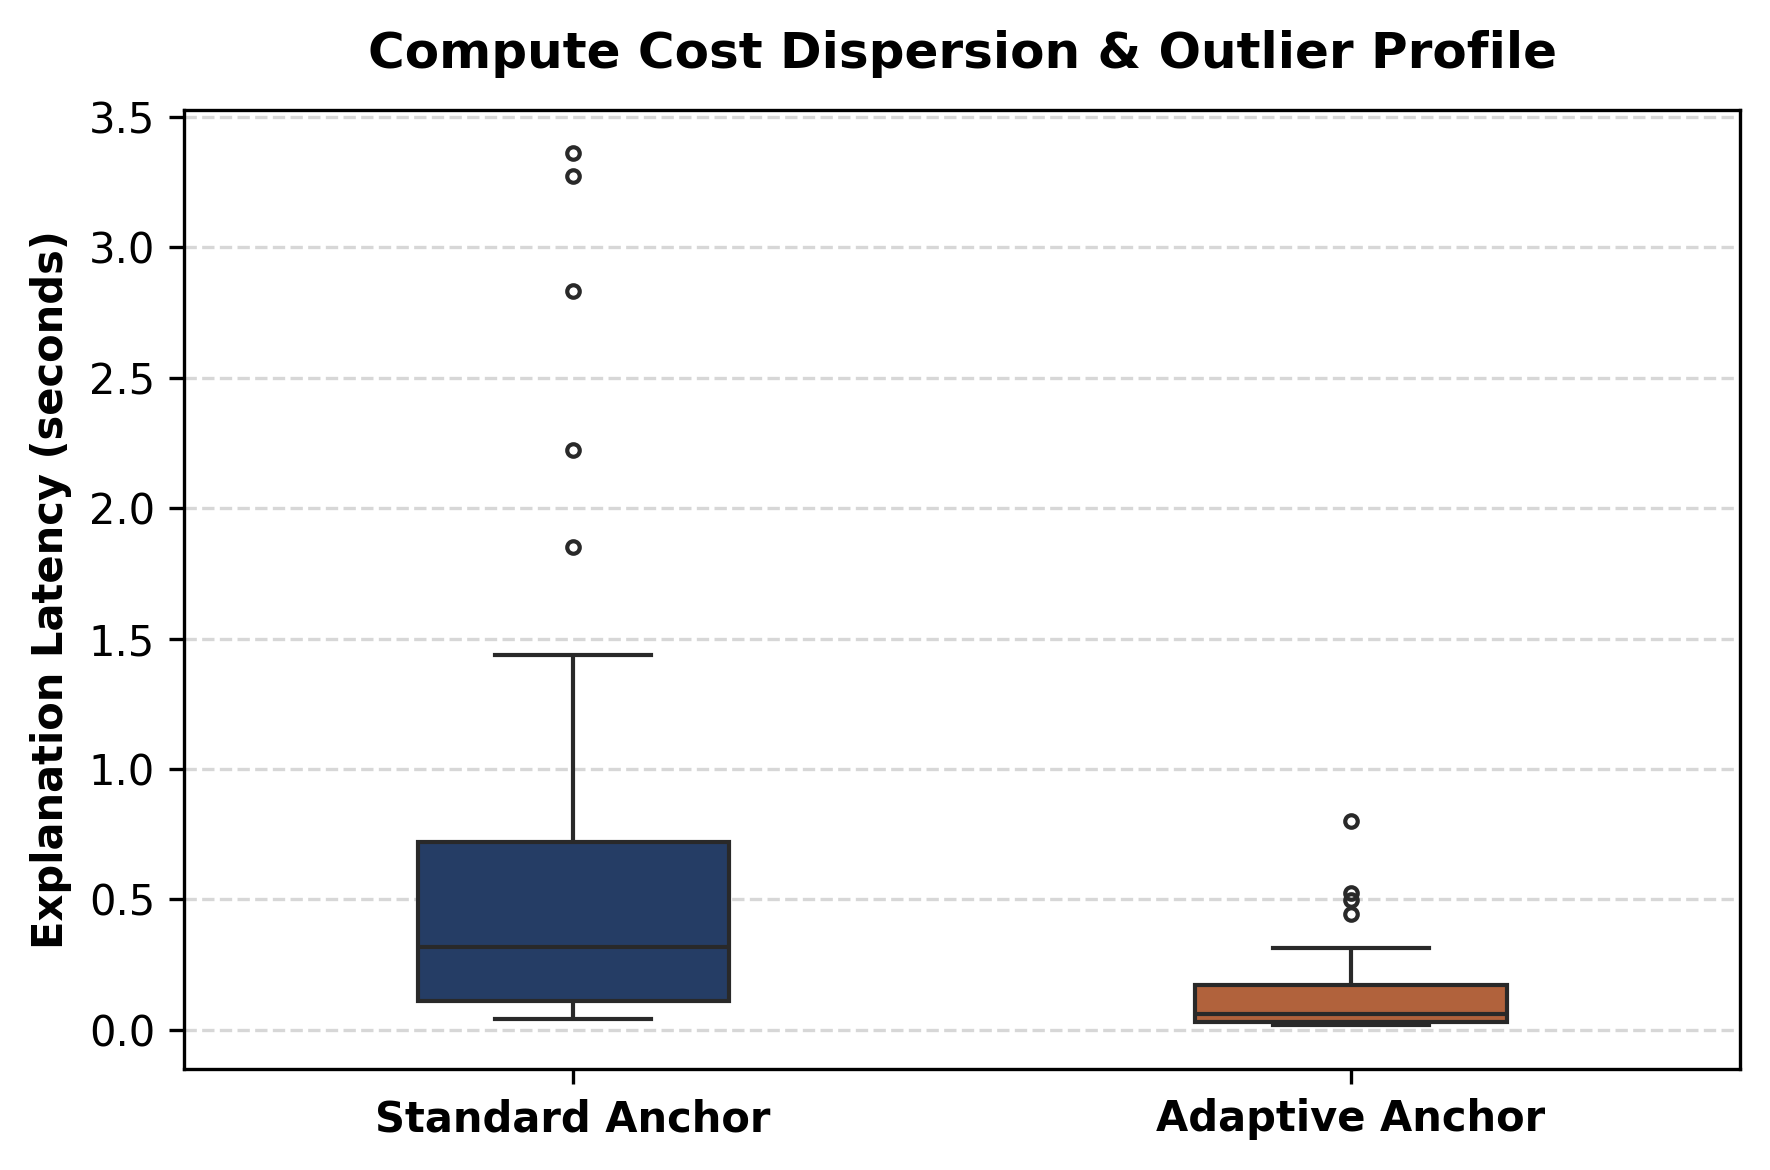

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Latency Variance Boxplot
plt.figure(figsize=(6, 4), dpi=300)
sns.boxplot(
    data=[all_results["Standard"]["time"], all_results["Adaptive"]["time"]],
    palette=['#1B3B6F', '#C45B28'],
    width=0.4,
    fliersize=3
)
plt.xticks([0, 1], ['Standard Anchor', 'Adaptive Anchor'], fontweight='bold')
plt.ylabel('Explanation Latency (seconds)', fontweight='bold')
plt.title('Compute Cost Dispersion & Outlier Profile', fontweight='bold', pad=10)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.savefig('latency_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

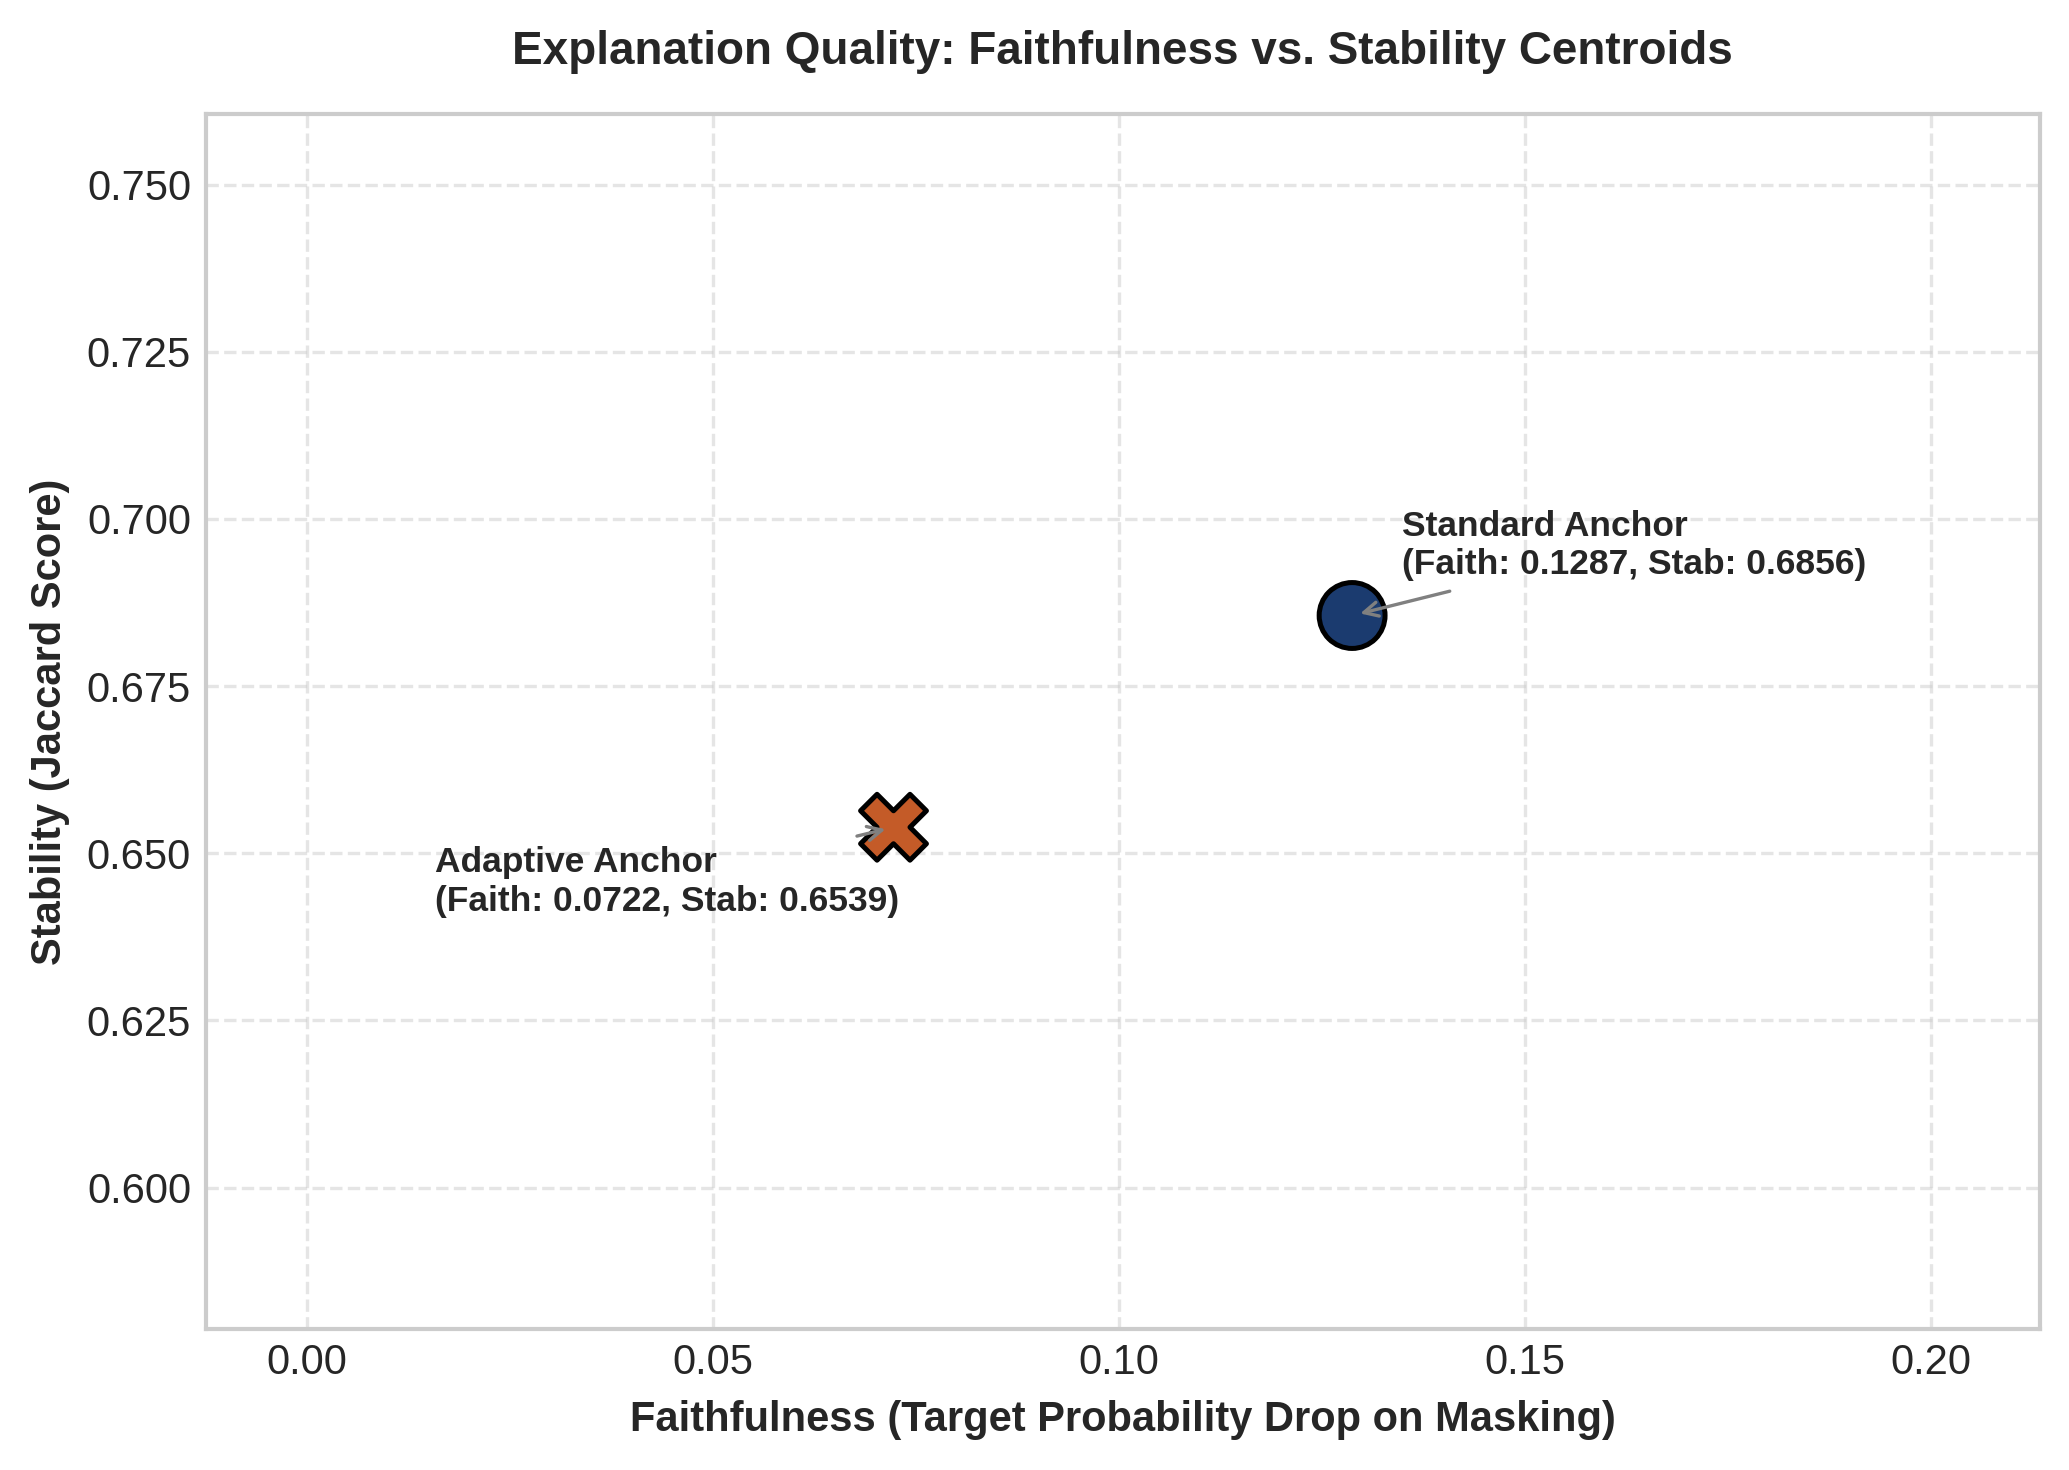

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Extract aggregate metrics safely from df_complete
faithfulness_std = df_complete.loc[df_complete['Method'] == 'Standard', 'Faithfulness'].iloc[0]
stability_std = df_complete.loc[df_complete['Method'] == 'Standard', 'Stability'].iloc[0]

faithfulness_adp = df_complete.loc[df_complete['Method'] == 'Adaptive', 'Faithfulness'].iloc[0]
stability_adp = df_complete.loc[df_complete['Method'] == 'Adaptive', 'Stability'].iloc[0]

methods = ['Standard Anchor', 'Adaptive Anchor']
faithfulness = [faithfulness_std, faithfulness_adp]
stability = [stability_std, stability_adp]

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# Plot centroids with clear styling
sns.scatterplot(
    x=faithfulness,
    y=stability,
    hue=methods,
    style=methods,
    s=250,
    ax=ax,
    palette={'Standard Anchor': '#1B3B6F', 'Adaptive Anchor': '#C45B28'},
    edgecolor='black',
    linewidth=1.2
)

# Text offsets and callout arrows to prevent label overlap
offsets = [(12, 10), (-110, -20)]

for i, method in enumerate(methods):
    ax.annotate(
        f"{method}\n(Faith: {faithfulness[i]:.4f}, Stab: {stability[i]:.4f})",
        xy=(faithfulness[i], stability[i]),
        xytext=offsets[i],
        textcoords="offset points",
        fontsize=8.5,
        fontweight='bold',
        arrowprops=dict(arrowstyle="->", color="gray", lw=0.8)
    )

ax.set_title('Explanation Quality: Faithfulness vs. Stability Centroids', fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Faithfulness (Target Probability Drop on Masking)', fontsize=10, fontweight='bold')
ax.set_ylabel('Stability (Jaccard Score)', fontsize=10, fontweight='bold')

# Dynamic axis padding to prevent division-by-zero or extreme scale distortion
f_span = max(abs(max(faithfulness) - min(faithfulness)), 0.002)
s_span = max(abs(max(stability) - min(stability)), 0.05)

ax.set_xlim(min(faithfulness) - f_span * 1.5, max(faithfulness) + f_span * 1.5)
ax.set_ylim(min(stability) - s_span * 1.5, max(stability) + s_span * 1.5)

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend().set_visible(False)
plt.tight_layout()
plt.savefig('faithfulness_vs_stability_centroid.png', dpi=300, bbox_inches='tight')
plt.show()